# Critical Infrastructure Vulnerability Envelope — Ukraine Setup Pipeline

## Overview

This notebook executes the **setup queries** for the Critical Infrastructure Vulnerability
Envelope (CIV) demo focused on **Ukraine**. It extracts real Overture Maps Foundation features
and synthetic social media feed data to build the spatial context layers that downstream
notional overlays and MCP-driven analysis will operate against.

**Pipeline steps:**
1. **AOI Localities** -- Extract administrative divisions for Ukraine and neighbors (PL, SK, HU, RO, MD, BY, RU)
2. **Critical Infrastructure Assets** -- Extract high-value assets (substations, dams, comm towers, pipelines, etc.)
3. **Flood Hazard Proximity** -- Count water features within 1 km of each asset (river, stream, lake, reservoir)
4. **Wildfire Hazard Proximity** -- Count fire-prone land cover within 500 m of each asset (forest, shrub)
5. **Settlement & Facility Proximity** -- Count nearby hospitals, schools, government offices (2 km) and buildings (1 km)
6. **Asset Criticality Tier** -- Assign criticality score (1-5) per asset class
7. **Seasonal Hazard Windows** -- Enrich assets with applicable hazard seasons (flood: Mar-Jun, wildfire: Jun-Sep)
8. **Social Media Sentiment Proximity** -- Aggregate synthetic tweet sentiment near each asset (5 km)
9. **Geofence Asset Overlay** -- Identify assets within monitoring geofences and correlate tweet activity
10. **Enhanced Vulnerability Score** -- 5-component weighted score: flood, wildfire, settlement, criticality, social signal
11. **Persist to Havasu Tables** -- Write all results to `wherobots.geoint.*_civ` Iceberg tables

**Distance calculations:**
All proximity calculations use `ST_DWithin(..., meters, useSpheroid=true)` -- geodesic meters.
Ukraine's AOI geometry is used only for `ST_Intersects` pre-filtering (no buffering needed).

**Data sources:**
- `wherobots_open_data.overture_maps_foundation.divisions_division_area`
- `wherobots_open_data.overture_maps_foundation.base_infrastructure`
- `wherobots_open_data.overture_maps_foundation.base_water`
- `wherobots_open_data.overture_maps_foundation.base_land_cover`
- `wherobots_open_data.overture_maps_foundation.places_place`
- `wherobots_open_data.overture_maps_foundation.buildings_building`
- `wherobots.space_kitty.geo_fence` (synthetic monitoring geofences)
- `wherobots.space_kitty.tweet_feed` (synthetic social media with sentiment)

**Output tables:** `wherobots.geoint.*_civ` (Havasu/Iceberg)

**Classification:** UNCLASSIFIED -- all Overture data is publicly available open data.
Social media feed data is **synthetic**. All operational indicators in downstream
notebooks are **notional/synthetic**.

## 1. Setup and Configuration

In [1]:
%%time
from sedona.spark import *
from pyspark.sql import functions as F
from viz import (
    plot_setup_step1_localities,
    plot_setup_step2_assets,
    plot_setup_step3_flood,
    plot_setup_step4_wildfire,
    plot_setup_step5_settlement,
    plot_setup_step6_tiers,
    plot_setup_step7_windows,
    plot_setup_step8_sentiment_gauge,
    plot_setup_step8_sentiment_bar,
    plot_setup_step9_geofence,
    plot_setup_step10_vuln_dist,
    plot_setup_step10_vuln_bubble,
    plot_setup_pipeline_summary,
)

config = SedonaContext.builder().getOrCreate()
sedona = SedonaContext.create(config)

print(f"Sedona context initialized")
print(f"Spark version: {sedona.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
Setting Spark log level to "WARN".
26/05/26 15:39:23 INFO core/src/lib.rs: Sedona native acceleration engine v0.12.7 ready
                                                                                

Sedona context initialized
Spark version: 4.0.1
CPU times: user 4.31 s, sys: 262 ms, total: 4.57 s
Wall time: 24.8 s


In [2]:
# =============================================================================
# Table References & Parameters
# =============================================================================

# Overture Maps Foundation tables (managed by Wherobots open data catalog)
DIVISIONS_TABLE      = "wherobots_open_data.overture_maps_foundation.divisions_division_area"
INFRASTRUCTURE_TABLE = "wherobots_open_data.overture_maps_foundation.base_infrastructure"
WATER_TABLE          = "wherobots_open_data.overture_maps_foundation.base_water"
LAND_COVER_TABLE     = "wherobots_open_data.overture_maps_foundation.base_land_cover"
PLACES_TABLE         = "wherobots_open_data.overture_maps_foundation.places_place"
BUILDINGS_TABLE      = "wherobots_open_data.overture_maps_foundation.buildings_building"

# Synthetic social media tables (Wherobots space_kitty catalog)
GEOFENCE_TABLE = "wherobots.space_kitty.geo_fence"
TWEET_TABLE    = "wherobots.space_kitty.tweet_feed"

# Output catalog and database (Havasu / Iceberg)
OUTPUT_CATALOG  = "wherobots"
OUTPUT_DATABASE = "geoint"
OUTPUT_PREFIX   = f"{OUTPUT_CATALOG}.{OUTPUT_DATABASE}"
TABLE_SUFFIX    = "_civ"  # appended to all table names to distinguish CIV variant

# Target country and neighbors
TARGET_COUNTRY = "UA"
NEIGHBOR_CODES = ["PL", "SK", "HU", "RO", "MD", "BY", "RU"]
ALL_CODES      = [TARGET_COUNTRY] + NEIGHBOR_CODES

# --- Critical infrastructure asset classes ---
# Excludes power_pole (18.3M) and power_tower (18.0M) -- too high-volume for demo spatial joins
ASSET_CLASSES = [
    "substation", "plant", "dam",
    "communication_tower", "mobile_phone_tower",
    "pipeline", "storage_tank", "water_tower",
    "generator", "transformer"
]

# --- Distance thresholds (all geodesic meters via useSpheroid=true) ---
FLOOD_BUFFER_M         = 1000   # 1 km -- flood hazard proximity
WILDFIRE_BUFFER_M      = 500    # 500 m -- wildfire hazard proximity
SETTLEMENT_PROXIMITY_M = 2000   # 2 km -- settlement/facility proximity
BUILDING_PROXIMITY_M   = 1000   # 1 km -- building density proximity
TWEET_PROXIMITY_M      = 5000   # 5 km -- social media signal radius

# --- Flood proxy: water feature classes ---
FLOOD_WATER_CLASSES = ["river", "stream", "lake", "reservoir", "canal"]

# --- Wildfire proxy: land cover subtypes ---
WILDFIRE_LAND_COVER_SUBTYPES = ["forest", "shrub"]

# --- Settlement facility categories ---
FACILITY_CATEGORIES = ["hospital", "school", "government_office"]

# --- Asset criticality tiers (1-5) ---
CRITICALITY_TIERS = {
    5: ["substation", "plant", "dam"],
    4: ["communication_tower", "mobile_phone_tower", "pipeline"],
    3: ["storage_tank", "water_tower"],
    2: ["generator", "transformer"],
}

# --- Enhanced vulnerability score weights (5 components) ---
W_FLOOD    = 0.25
W_WILDFIRE = 0.25
W_SETTLE   = 0.15
W_CRITICAL = 0.20
W_SOCIAL   = 0.15

print("Configuration loaded")
print(f"  Target: {TARGET_COUNTRY} + neighbors: {NEIGHBOR_CODES}")
print(f"  Asset classes: {ASSET_CLASSES}")
print(f"  Distance thresholds: flood={FLOOD_BUFFER_M} m, wildfire={WILDFIRE_BUFFER_M} m")
print(f"                       settlement={SETTLEMENT_PROXIMITY_M} m, building={BUILDING_PROXIMITY_M} m")
print(f"                       social media={TWEET_PROXIMITY_M} m")
print(f"  All proximity: useSpheroid=true (geodesic meters)")
print(f"  Vulnerability weights: flood={W_FLOOD}, wildfire={W_WILDFIRE}, settle={W_SETTLE}, critical={W_CRITICAL}, social={W_SOCIAL}")
print(f"  Social media: {GEOFENCE_TABLE}, {TWEET_TABLE}")
print(f"  Output: {OUTPUT_PREFIX}.*{TABLE_SUFFIX}")
print(f"  No result limits -- full Ukraine scope")

Configuration loaded
  Target: UA + neighbors: ['PL', 'SK', 'HU', 'RO', 'MD', 'BY', 'RU']
  Asset classes: ['substation', 'plant', 'dam', 'communication_tower', 'mobile_phone_tower', 'pipeline', 'storage_tank', 'water_tower', 'generator', 'transformer']
  Distance thresholds: flood=1000 m, wildfire=500 m
                       settlement=2000 m, building=1000 m
                       social media=5000 m
  All proximity: useSpheroid=true (geodesic meters)
  Vulnerability weights: flood=0.25, wildfire=0.25, settle=0.15, critical=0.2, social=0.15
  Social media: wherobots.space_kitty.geo_fence, wherobots.space_kitty.tweet_feed
  Output: wherobots.geoint.*_civ
  No result limits -- full Ukraine scope


---
## Step 1 -- AOI Localities

Extract administrative divisions for Ukraine and its seven neighbors.
Then union Ukraine divisions into a single AOI geometry for downstream spatial filters.

Ukraine's extensive border zone -- from Poland in the west to Russia in the east --
spans one of the longest combined border lengths in Europe, with critical
infrastructure distributed across diverse terrain from the Carpathian Mountains
to the Dnipro River basin.

**Source:** `sql/01_aoi_localities.sql`

In [3]:
%%time
# =============================================================================
# Step 1a: AOI Localities -- Ukraine + PL, SK, HU, RO, MD, BY, RU
# =============================================================================

country_list = ", ".join([f"'{c}'" for c in ALL_CODES])

aoi_localities = sedona.sql(f"""
    SELECT
      id,
      names,
      subtype,
      country,
      region,
      geometry
    FROM {DIVISIONS_TABLE}
    WHERE country IN ({country_list})
""")

aoi_localities = aoi_localities.cache()
aoi_localities.createOrReplaceTempView("aoi_localities")

aoi_count = aoi_localities.count()
print(f"AOI localities extracted: {aoi_count:,}")

[Stage 3:=======================================================> (89 + 2) / 91]

AOI localities extracted: 245,745
CPU times: user 15.2 ms, sys: 0 ns, total: 15.2 ms
Wall time: 6.84 s


In [4]:
%%time
# =============================================================================
# Step 1b: Union Ukraine divisions into a single AOI geometry
# =============================================================================

ukraine_aoi = sedona.sql(f"""
    SELECT ST_Union_Aggr(geometry) AS geometry
    FROM {DIVISIONS_TABLE}
    WHERE country = '{TARGET_COUNTRY}'
""")

ukraine_aoi.cache()
ukraine_aoi.createOrReplaceTempView("ukraine_aoi")

print("Ukraine AOI geometry created")

# --- SedonaKepler: Ukraine AOI boundary map ---
aoi_map = SedonaKepler.create_map(df=ukraine_aoi, name="Ukraine AOI")
aoi_map;


Ukraine AOI geometry created


[Stage 9:>                                                          (0 + 1) / 1]

CPU times: user 333 ms, sys: 18.9 ms, total: 351 ms
Wall time: 17.7 s


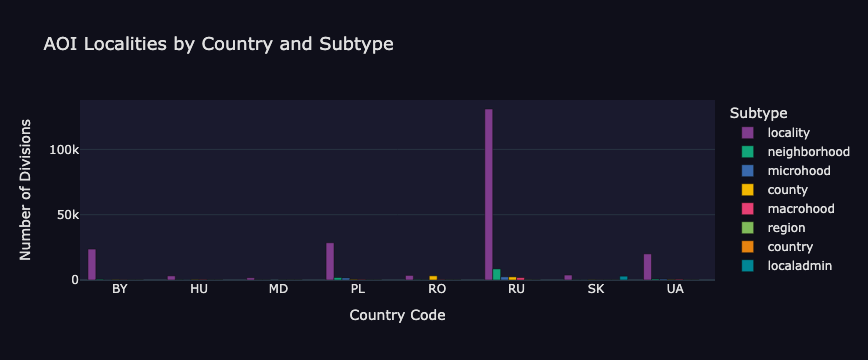

In [5]:
# =============================================================================
# Step 1 Visualization -- AOI Localities
# =============================================================================

country_pd = aoi_localities.groupBy("country", "subtype").count() \
    .orderBy("country", F.desc("count")).toPandas()

plot_setup_step1_localities(country_pd)

---
## Step 2 -- Critical Infrastructure Assets

Extract high-value infrastructure assets from `base_infrastructure` within Ukraine.
These are the **primary analytic units** for the CIV demo -- each asset will be scored
for multi-hazard vulnerability and correlated with social media signals.

**Included asset classes:**
- **Power:** substation, plant, generator, transformer
- **Communication:** communication_tower, mobile_phone_tower
- **Utility:** pipeline, storage_tank, water_tower
- **Water:** dam

**Excluded:** `power_pole` (18.3M global) and `power_tower` (18.0M global) -- too
high-volume for spatial joins in a demo context.

**Source:** `sql/02_critical_infrastructure_assets.sql`

In [6]:
%%time
# =============================================================================
# Step 2: Critical Infrastructure Assets within Ukraine
# =============================================================================

asset_class_list = ", ".join([f"'{c}'" for c in ASSET_CLASSES])

critical_assets = sedona.sql(f"""
    SELECT
      i.id AS asset_id,
      i.subtype,
      i.class,
      i.names,
      i.geometry
    FROM {INFRASTRUCTURE_TABLE} i
    JOIN ukraine_aoi ua
      ON ST_Intersects(ua.geometry, i.geometry)
    WHERE i.class IN ({asset_class_list})
""")

critical_assets = critical_assets.cache()
critical_assets.createOrReplaceTempView("critical_assets")

asset_count = critical_assets.count()
print(f"Critical infrastructure assets extracted: {asset_count:,}")

[Stage 22:=====================================================>(228 + 1) / 229]

Critical infrastructure assets extracted: 78,393
CPU times: user 13.6 ms, sys: 0 ns, total: 13.6 ms
Wall time: 16.7 s


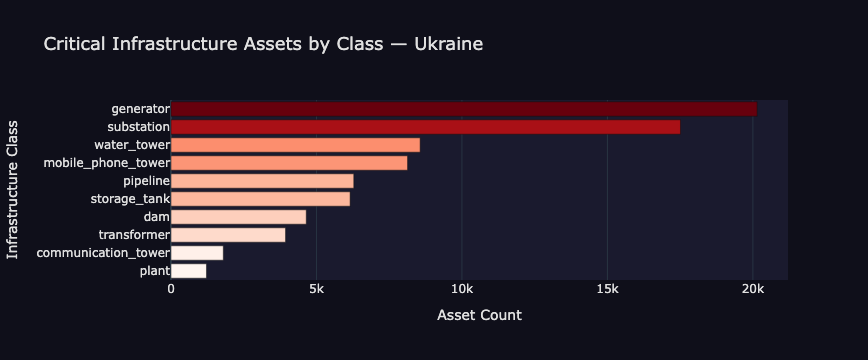

In [7]:
# =============================================================================
# Step 2 Visualization -- Critical Infrastructure Assets
# =============================================================================

class_pd = critical_assets.groupBy("class").count() \
    .orderBy(F.desc("count")).toPandas()

plot_setup_step2_assets(class_pd)

# --- SedonaKepler: all critical assets scatter map colored by class ---
asset_map_df = critical_assets.select("asset_id", "class", "subtype", "geometry")
asset_map = SedonaKepler.create_map(df=asset_map_df, name="Critical Assets")
asset_map;

---
## Step 3 -- Flood Hazard Proximity

Count water features (river, stream, lake, reservoir, canal) within 1 km of each
critical infrastructure asset. Water proximity serves as a **flood hazard proxy** --
assets near the Dnipro, Dnister, Southern Bug, and Desna river systems face
elevated flood risk during spring snowmelt (March-June) and heavy rain events.

**Distance:** `ST_DWithin(..., 1000, true)` -- geodesic meters via `useSpheroid`

**Pre-filter:** Water features are first filtered to Ukraine via a `WITH ukraine_water` CTE
using `JOIN ukraine_aoi ON ST_Intersects(...)` before the `ST_DWithin` distance join.
This reduces the global water dataset to Ukraine scope before the more expensive
distance calculation, allowing Sedona's advanced spatial join optimizer to operate
on a smaller, bounded input.

**Uses:** `critical_assets` and `ukraine_aoi` temp views

**Source:** `sql/03_flood_hazard_proximity.sql`

In [8]:
%%time
# =============================================================================
# Step 3: Flood hazard proximity -- water features within FLOOD_BUFFER_M
# =============================================================================
# Pre-filters water features to Ukraine AOI, then counts per asset.
# ST_DWithin with useSpheroid=true interprets distance in geodesic meters.

water_class_list = ", ".join([f"'{c}'" for c in FLOOD_WATER_CLASSES])

flood_proximity = sedona.sql(f"""
    WITH ukraine_water AS (
      SELECT w.id, w.geometry
      FROM {WATER_TABLE} w
      JOIN ukraine_aoi ua ON ST_Intersects(ua.geometry, w.geometry)
      WHERE w.class IN ({water_class_list})
    )
    SELECT
      a.asset_id,
      COUNT(w.id) AS flood_water_count
    FROM critical_assets a
    JOIN ukraine_water w
      ON ST_DWithin(a.geometry, w.geometry, {FLOOD_BUFFER_M}, true)
    GROUP BY a.asset_id
    ORDER BY flood_water_count DESC
""")

flood_proximity = flood_proximity.cache()
flood_proximity.createOrReplaceTempView("flood_proximity")

flood_hit_count = flood_proximity.count()
print(f"Assets with nearby water features (flood proxy): {flood_hit_count:,}")

Assets with nearby water features (flood proxy): 38,099
CPU times: user 25.2 ms, sys: 11.6 ms, total: 36.8 ms
Wall time: 1min 3s


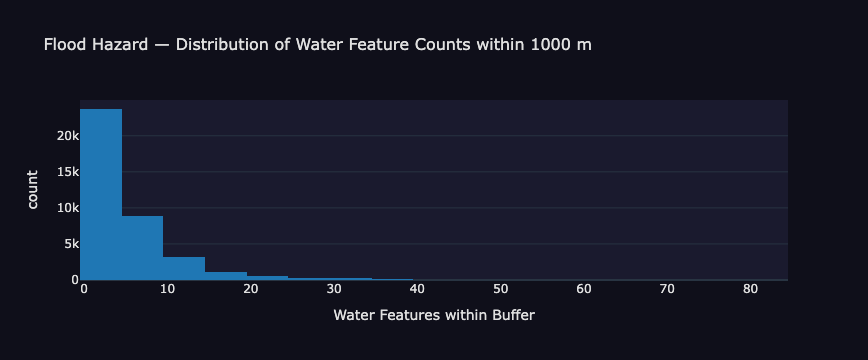

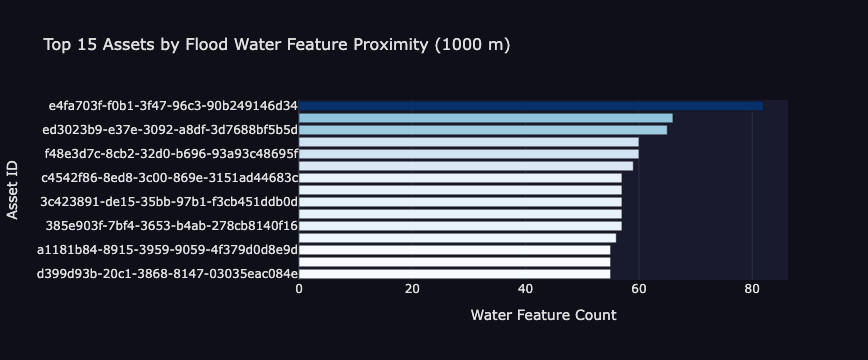

In [9]:
# =============================================================================
# Step 3 Visualization -- Flood Hazard Proximity
# =============================================================================

flood_pd = flood_proximity.select("asset_id", "flood_water_count").toPandas()
top_flood_pd = flood_proximity.orderBy(F.desc("flood_water_count")).limit(15).toPandas()

plot_setup_step3_flood(flood_pd, top_flood_pd, FLOOD_BUFFER_M)

---
## Step 4 -- Wildfire Hazard Proximity

Count fire-prone land cover (forest, shrub) within 500 m of each critical
infrastructure asset. Proximity to combustible vegetation serves as a
**wildfire hazard proxy** -- assets surrounded by forest and shrubland face
elevated risk during Ukraine's summer drought season (June-September),
particularly in the Carpathian and Polissia forest zones.

**Distance:** `ST_DWithin(..., 500, true)` -- geodesic meters via `useSpheroid`

**Pre-filter:** Land cover features are first filtered to Ukraine via a `WITH ukraine_landcover`
CTE using `JOIN ukraine_aoi ON ST_Intersects(...)` before the `ST_DWithin` distance join.
This is essential -- `base_land_cover` has very high global volume (~55M forest + shrub
features). The CTE bounds the dataset to Ukraine before the expensive distance scan.

**Uses:** `critical_assets` and `ukraine_aoi` temp views

**Source:** `sql/04_wildfire_hazard_proximity.sql`

In [10]:
%%time
# =============================================================================
# Step 4: Wildfire hazard proximity -- fire-prone land cover within WILDFIRE_BUFFER_M
# =============================================================================
# Pre-filters land cover to Ukraine AOI, then counts per asset.
# base_land_cover is very high volume; the Ukraine AOI filter is essential.
# ST_DWithin with useSpheroid=true interprets distance in geodesic meters.

wildfire_subtype_list = ", ".join([f"'{s}'" for s in WILDFIRE_LAND_COVER_SUBTYPES])

wildfire_proximity = sedona.sql(f"""
    WITH ukraine_landcover AS (
      SELECT lc.id, lc.geometry
      FROM {LAND_COVER_TABLE} lc
      JOIN ukraine_aoi ua ON ST_Intersects(ua.geometry, lc.geometry)
      WHERE lc.subtype IN ({wildfire_subtype_list})
    )
    SELECT
      a.asset_id,
      COUNT(lc.id) AS wildfire_landcover_count
    FROM critical_assets a
    JOIN ukraine_landcover lc
      ON ST_DWithin(a.geometry, lc.geometry, {WILDFIRE_BUFFER_M}, true)
    GROUP BY a.asset_id
    ORDER BY wildfire_landcover_count DESC
""")

wildfire_proximity = wildfire_proximity.cache()
wildfire_proximity.createOrReplaceTempView("wildfire_proximity")

wildfire_hit_count = wildfire_proximity.count()
print(f"Assets with nearby fire-prone land cover (wildfire proxy): {wildfire_hit_count:,}")

Assets with nearby fire-prone land cover (wildfire proxy): 49,749
CPU times: user 60.1 ms, sys: 2.11 ms, total: 62.2 ms
Wall time: 1min 1s


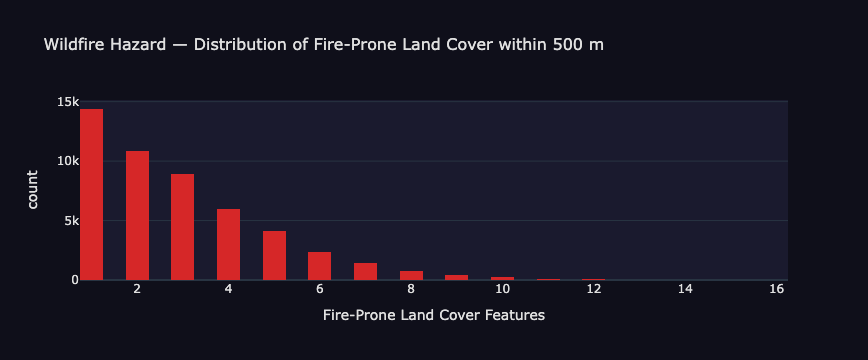

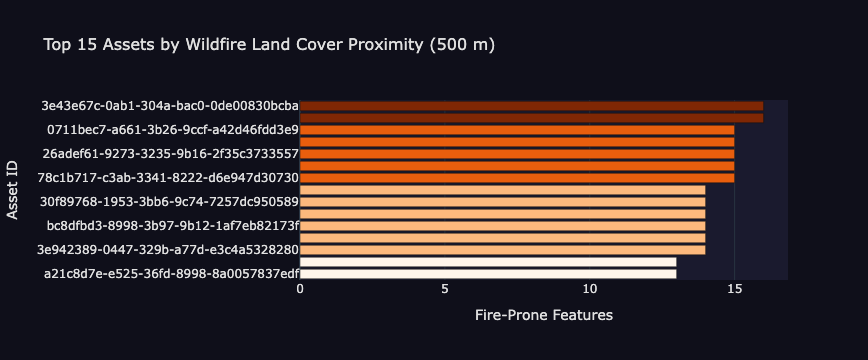

In [11]:
# =============================================================================
# Step 4 Visualization -- Wildfire Hazard Proximity
# =============================================================================

wildfire_pd = wildfire_proximity.select("asset_id", "wildfire_landcover_count").toPandas()
top_wf_pd = wildfire_proximity.orderBy(F.desc("wildfire_landcover_count")).limit(15).toPandas()

plot_setup_step4_wildfire(wildfire_pd, top_wf_pd, WILDFIRE_BUFFER_M)

---
## Step 5 -- Settlement & Facility Proximity

Assess the human-impact dimension of each asset's vulnerability:

- **5a: Facility proximity** -- Count nearby hospitals, schools, government offices
  within 2 km. High facility counts indicate populated areas where infrastructure
  failure would have greater cascading consequences.

- **5b: Building density** -- Count nearby building footprints within 1 km.
  Dense built environment near critical assets amplifies both the consequence
  of failure and the challenge of emergency response.

**Source:** `sql/05_settlement_facility_proximity.sql`

In [12]:
%%time
# =============================================================================
# Step 5a: Settlement/facility proximity -- places within SETTLEMENT_PROXIMITY_M
# =============================================================================
# Counts hospitals, schools, government offices near each critical asset.
# ST_DWithin with useSpheroid=true interprets distance in geodesic meters.

facility_cat_list = ", ".join([f"'{c}'" for c in FACILITY_CATEGORIES])

settlement_proximity = sedona.sql(f"""
    WITH ukraine_facilities AS (
      SELECT p.id, p.geometry
      FROM {PLACES_TABLE} p
      JOIN ukraine_aoi ua ON ST_Intersects(ua.geometry, p.geometry)
      WHERE p.categories.primary IN ({facility_cat_list})
    )
    SELECT
      a.asset_id,
      COUNT(p.id) AS facility_count
    FROM critical_assets a
    JOIN ukraine_facilities p
      ON ST_DWithin(a.geometry, p.geometry, {SETTLEMENT_PROXIMITY_M}, true)
    GROUP BY a.asset_id
    ORDER BY facility_count DESC
""")

settlement_proximity = settlement_proximity.cache()
settlement_proximity.createOrReplaceTempView("settlement_proximity")

settle_hit_count = settlement_proximity.count()
print(f"Assets with nearby facilities (hospitals, schools, govt): {settle_hit_count:,}")

Assets with nearby facilities (hospitals, schools, govt): 23,566
CPU times: user 8.3 ms, sys: 0 ns, total: 8.3 ms
Wall time: 5.86 s


In [13]:
%%time
# =============================================================================
# Step 5b: Building density -- buildings within BUILDING_PROXIMITY_M
# =============================================================================
# Counts building footprints near each critical asset.
# ST_DWithin with useSpheroid=true interprets distance in geodesic meters.

building_density = sedona.sql(f"""
    WITH ukraine_buildings AS (
      SELECT b.id, b.geometry
      FROM {BUILDINGS_TABLE} b
      JOIN ukraine_aoi ua ON ST_Intersects(ua.geometry, b.geometry)
    )
    SELECT
      a.asset_id,
      COUNT(b.id) AS building_count
    FROM critical_assets a
    JOIN ukraine_buildings b
      ON ST_DWithin(a.geometry, b.geometry, {BUILDING_PROXIMITY_M}, true)
    GROUP BY a.asset_id
    ORDER BY building_count DESC
""")

building_density = building_density.cache()
building_density.createOrReplaceTempView("building_density")

bld_hit_count = building_density.count()
print(f"Assets with nearby buildings: {bld_hit_count:,}")

Assets with nearby buildings: 76,644
CPU times: user 195 ms, sys: 29.8 ms, total: 225 ms
Wall time: 20min 5s


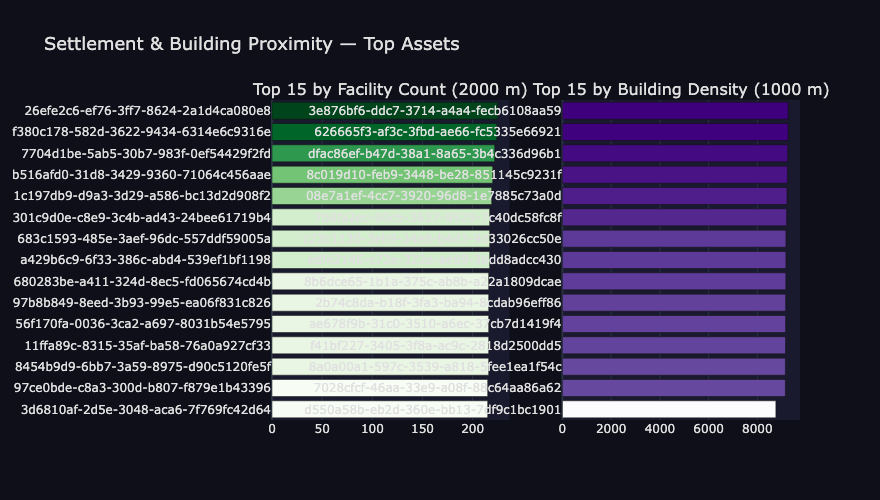

In [14]:
# =============================================================================
# Step 5 Visualization -- Settlement & Facility / Building Proximity
# =============================================================================

top_fac_pd = settlement_proximity.orderBy(F.desc("facility_count")).limit(15).toPandas()
top_bld_pd = building_density.orderBy(F.desc("building_count")).limit(15).toPandas()

plot_setup_step5_settlement(top_fac_pd, top_bld_pd, SETTLEMENT_PROXIMITY_M, BUILDING_PROXIMITY_M)

---
## Step 6 -- Asset Criticality Tier

Assign a criticality tier (1-5) to each asset based on its infrastructure class.
Higher tiers indicate greater consequence of failure:

| Tier | Asset Classes | Rationale |
|------|--------------|----------|
| 5 | substation, plant, dam | Regional power/water backbone -- cascading failure potential |
| 4 | communication_tower, mobile_phone_tower, pipeline | Connectivity & fuel distribution -- wide-area impact |
| 3 | storage_tank, water_tower | Local utility -- single-community impact |
| 2 | generator, transformer | Distributed power components -- redundancy available |

**Source:** `sql/06_asset_criticality_tier.sql`

In [15]:
%%time
# =============================================================================
# Step 6: Asset criticality tier assignment
# =============================================================================
# Assigns a 1-5 tier score based on asset class.
# Uses the critical_assets temp view from Step 2.

# Build CASE WHEN dynamically from CRITICALITY_TIERS dict
case_clauses = []
for tier, classes in sorted(CRITICALITY_TIERS.items(), reverse=True):
    class_list = ", ".join([f"'{c}'" for c in classes])
    case_clauses.append(f"WHEN class IN ({class_list}) THEN {tier}")
case_expr = " ".join(case_clauses)

asset_criticality = sedona.sql(f"""
    SELECT
      asset_id,
      subtype,
      class,
      CASE {case_expr} ELSE 1 END AS criticality_tier
    FROM critical_assets
""")

asset_criticality = asset_criticality.cache()
asset_criticality.createOrReplaceTempView("asset_criticality")

crit_count = asset_criticality.count()
print(f"Assets with criticality tier assigned: {crit_count:,}")

Assets with criticality tier assigned: 78,393
CPU times: user 2.53 ms, sys: 0 ns, total: 2.53 ms
Wall time: 274 ms


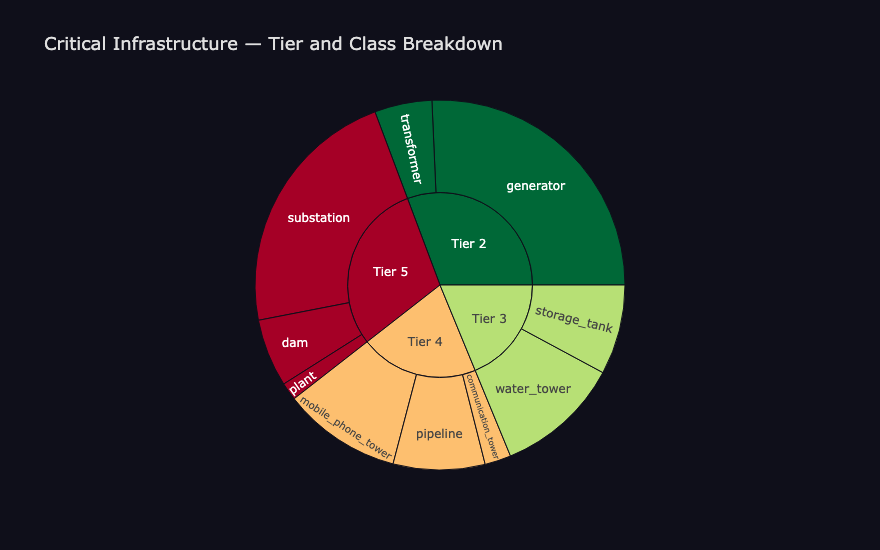

In [16]:
# =============================================================================
# Step 6 Visualization -- Asset Criticality Tiers
# =============================================================================

tier_class_pd = asset_criticality.groupBy("criticality_tier", "class").count() \
    .orderBy(F.desc("criticality_tier"), F.desc("count")).toPandas()
tier_class_pd["tier_label"] = "Tier " + tier_class_pd["criticality_tier"].astype(str)

plot_setup_step6_tiers(tier_class_pd)

---
## Step 7 -- Seasonal Hazard Windows

Enrich each asset with applicable **seasonal hazard windows** -- the time periods
when each hazard type is most likely to affect the asset.

| Season | Months | Hazard | Driver |
|--------|--------|--------|--------|
| Flood | Mar -- Jun | Snowmelt + spring rains | Carpathian runoff, Dnipro/Dnister basin flooding |
| Wildfire | Jun -- Sep | Summer drought + agricultural burning | Low humidity, dry vegetation in forest/steppe zones |
| Peak vulnerability | Mar -- Sep | Both hazards overlap | Multi-hazard assets face extended 7-month exposure window |

**Source:** `sql/08_seasonal_hazard_windows.sql`

In [17]:
%%time
# =============================================================================
# Step 7: Seasonal hazard windows
# =============================================================================
# Enriches each asset with applicable hazard seasons based on proximity results.
# Requires flood_proximity and wildfire_proximity temp views.

seasonal_vulnerability = sedona.sql("""
    SELECT
      ca.asset_id,
      COALESCE(fp.flood_water_count, 0) AS flood_count,
      COALESCE(wp.wildfire_landcover_count, 0) AS wildfire_count,
      CASE WHEN COALESCE(fp.flood_water_count, 0) > 0 THEN 'Mar-Jun' ELSE NULL END AS flood_season,
      CASE WHEN COALESCE(wp.wildfire_landcover_count, 0) > 0 THEN 'Jun-Sep' ELSE NULL END AS wildfire_season,
      CASE
        WHEN COALESCE(fp.flood_water_count, 0) > 0 AND COALESCE(wp.wildfire_landcover_count, 0) > 0 THEN 'Mar-Sep'
        WHEN COALESCE(fp.flood_water_count, 0) > 0 THEN 'Mar-Jun'
        WHEN COALESCE(wp.wildfire_landcover_count, 0) > 0 THEN 'Jun-Sep'
        ELSE NULL
      END AS peak_vulnerability_window,
      CASE
        WHEN COALESCE(fp.flood_water_count, 0) > 0 AND COALESCE(wp.wildfire_landcover_count, 0) > 0 THEN 7
        WHEN COALESCE(fp.flood_water_count, 0) > 0 OR COALESCE(wp.wildfire_landcover_count, 0) > 0 THEN 4
        ELSE 0
      END AS hazard_months_per_year
    FROM critical_assets ca
    LEFT JOIN flood_proximity fp ON ca.asset_id = fp.asset_id
    LEFT JOIN wildfire_proximity wp ON ca.asset_id = wp.asset_id
""")

seasonal_vulnerability = seasonal_vulnerability.cache()
seasonal_vulnerability.createOrReplaceTempView("seasonal_vulnerability")

seasonal_count = seasonal_vulnerability.count()
print(f"Assets with seasonal enrichment: {seasonal_count:,}")

Assets with seasonal enrichment: 78,393
CPU times: user 2.22 ms, sys: 126 μs, total: 2.35 ms
Wall time: 728 ms


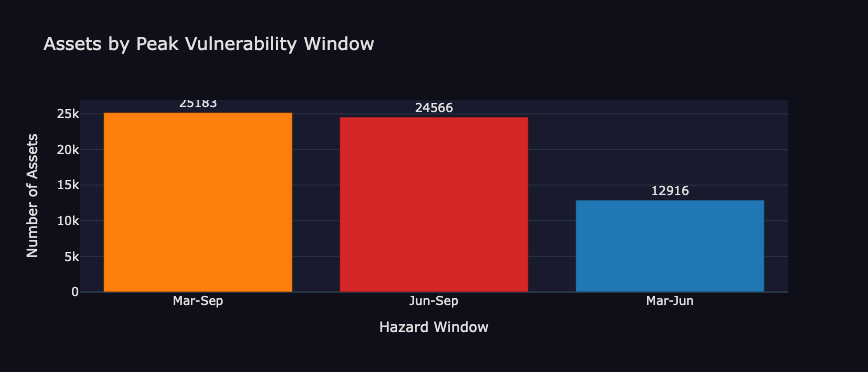

In [18]:
# =============================================================================
# Step 7 Visualization -- Seasonal Hazard Windows
# =============================================================================

window_pd = seasonal_vulnerability.groupBy("peak_vulnerability_window").count() \
    .orderBy(F.desc("count")).toPandas()

plot_setup_step7_windows(window_pd)

# --- SedonaKepler: assets colored by peak_vulnerability_window ---
window_map_df = seasonal_vulnerability.select(
    "asset_id", "peak_vulnerability_window", "hazard_months_per_year", "geometry"
)
window_map = SedonaKepler.create_map(df=window_map_df, name="Hazard Windows")
window_map

---
## Step 8 -- Social Media Sentiment Proximity

Spatially join **synthetic tweet feed** data to critical infrastructure assets.
Tweets within 5 km of each asset are aggregated to produce a **social media
signal** -- sentiment distribution, engagement metrics, and event type diversity.

Negative sentiment spikes near critical infrastructure may indicate:
- Reported outages or damage
- Public concern about infrastructure condition
- Emerging hazard events (flooding, fire, conflict damage)

**Distance:** `ST_DWithin(..., 5000, true)` -- geodesic meters via `useSpheroid`

**Data source:** `wherobots.space_kitty.tweet_feed` (synthetic)

**Source:** `sql/09_social_media_proximity.sql`

In [19]:
%%time
# =============================================================================
# Step 8: Social media sentiment proximity
# =============================================================================
# Spatially joins tweets to critical assets within TWEET_PROXIMITY_M.
# Aggregates sentiment, engagement, and event type per asset.

social_media_proximity = sedona.sql(f"""
    SELECT
      a.asset_id,
      COUNT(t.tweet_id) AS tweet_count,
      ROUND(AVG(t.sentiment_score), 4) AS avg_sentiment_score,
      SUM(CASE WHEN t.sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_tweet_count,
      SUM(CASE WHEN t.sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_tweet_count,
      SUM(CASE WHEN t.sentiment_label = 'neutral' THEN 1 ELSE 0 END) AS neutral_tweet_count,
      SUM(t.retweet_count) AS total_retweets,
      SUM(t.like_count) AS total_likes,
      COUNT(DISTINCT t.event_type) AS distinct_event_types,
      COUNT(DISTINCT t.user_handle) AS distinct_users
    FROM critical_assets a
    JOIN {TWEET_TABLE} t
      ON ST_DWithin(a.geometry, t.geometry, {TWEET_PROXIMITY_M}, true)
    GROUP BY a.asset_id
    ORDER BY tweet_count DESC
""")

social_media_proximity = social_media_proximity.cache()
social_media_proximity.createOrReplaceTempView("social_media_proximity")

social_hit_count = social_media_proximity.count()
print(f"Assets with nearby tweets ({TWEET_PROXIMITY_M} m): {social_hit_count:,}")

Assets with nearby tweets (5000 m): 23,032
CPU times: user 44.1 ms, sys: 1.95 ms, total: 46 ms
Wall time: 22.9 s


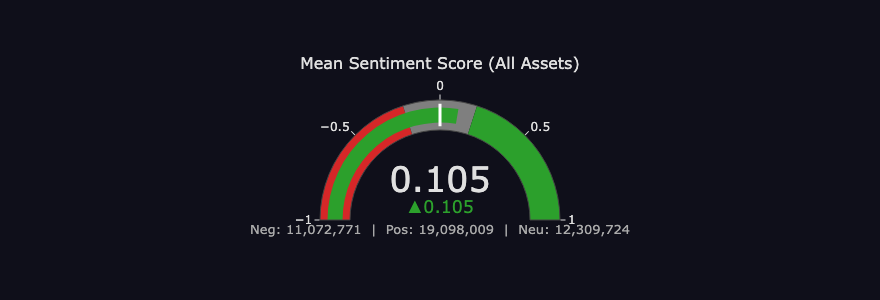

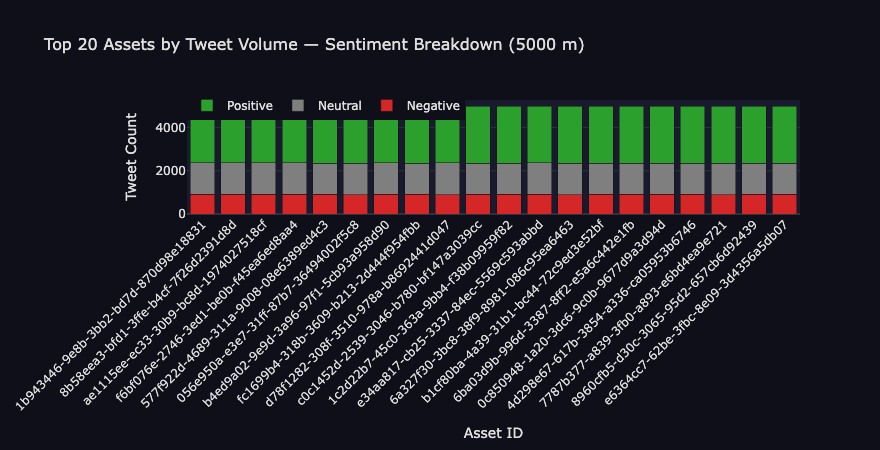

In [20]:
# =============================================================================
# Step 8 Visualization -- Social Media Sentiment Proximity
# =============================================================================

agg_pd = social_media_proximity.select(
    F.sum("tweet_count").alias("total_tweets"),
    F.sum("negative_tweet_count").alias("total_negative"),
    F.sum("positive_tweet_count").alias("total_positive"),
    F.sum("neutral_tweet_count").alias("total_neutral"),
    F.round(F.avg("avg_sentiment_score"), 4).alias("mean_sentiment"),
).toPandas()

total_neg  = int(agg_pd["total_negative"].iloc[0])
total_pos  = int(agg_pd["total_positive"].iloc[0])
total_neu  = int(agg_pd["total_neutral"].iloc[0])
mean_sent  = float(agg_pd["mean_sentiment"].iloc[0])

plot_setup_step8_sentiment_gauge(total_neg, total_pos, total_neu, mean_sent, TWEET_PROXIMITY_M)

top_social_pd = (
    social_media_proximity
    .filter(F.col("tweet_count") > 0)
    .orderBy(F.desc("tweet_count"))
    .limit(20)
    .select("asset_id", "negative_tweet_count", "neutral_tweet_count", "positive_tweet_count")
    .toPandas()
)

plot_setup_step8_sentiment_bar(top_social_pd, TWEET_PROXIMITY_M)

---
## Step 9 -- Geofence Asset Overlay

Identify which critical infrastructure assets fall within **monitoring geofences**
and correlate with social media activity within those geofences.

Geofences represent designated monitoring zones -- areas of heightened interest
where infrastructure status and social signals are actively tracked. Assets
inside geofences that also show negative social media sentiment are flagged
as high-priority monitoring targets.

**Data source:** `wherobots.space_kitty.geo_fence` (synthetic)

**Source:** `sql/10_geofence_asset_overlay.sql`

In [21]:
%%time
# =============================================================================
# Step 9: Geofence asset overlay
# =============================================================================
# Identifies which assets fall within monitoring geofences.
# Joins geofence tweet activity from tweet_feed (where in_fence = true).

geofence_asset_overlay = sedona.sql(f"""
    WITH asset_in_fence AS (
      SELECT
        ca.asset_id,
        gf.id AS geofence_id,
        TRUE AS in_geofence
      FROM critical_assets ca
      JOIN {GEOFENCE_TABLE} gf
        ON ST_Intersects(gf.geometry, ca.geometry)
    ),
    fence_tweet_activity AS (
      SELECT
        gf.id AS geofence_id,
        COUNT(t.tweet_id) AS fence_tweet_count,
        SUM(CASE WHEN t.sentiment_label = 'negative' THEN 1 ELSE 0 END) AS fence_negative_tweets,
        ROUND(AVG(t.sentiment_score), 4) AS fence_avg_sentiment,
        gf.geometry
        
      FROM {GEOFENCE_TABLE} gf
      JOIN {TWEET_TABLE} t
        ON ST_Intersects(gf.geometry, t.geometry)
      GROUP BY gf.id
    )
    SELECT
      af.asset_id,
      af.geofence_id,
      af.in_geofence,
      COALESCE(ft.fence_tweet_count, 0) AS fence_tweet_count,
      COALESCE(ft.fence_negative_tweets, 0) AS fence_negative_tweets,
      ft.fence_avg_sentiment,
      ft.geometry AS geofence_geometry
    FROM asset_in_fence af
    LEFT JOIN fence_tweet_activity ft ON af.geofence_id = ft.geofence_id
    ORDER BY fence_negative_tweets DESC
""")

geofence_asset_overlay = geofence_asset_overlay.cache()
geofence_asset_overlay.createOrReplaceTempView("geofence_asset_overlay")

geofence_count = geofence_asset_overlay.count()
print(f"Assets within monitoring geofences: {geofence_count:,}")

Assets within monitoring geofences: 12,019
CPU times: user 31.9 ms, sys: 203 μs, total: 32.1 ms
Wall time: 12.6 s


In [26]:
geofence_asset_overlay.columns

['asset_id',
 'geofence_id',
 'in_geofence',
 'fence_tweet_count',
 'fence_negative_tweets',
 'fence_avg_sentiment']

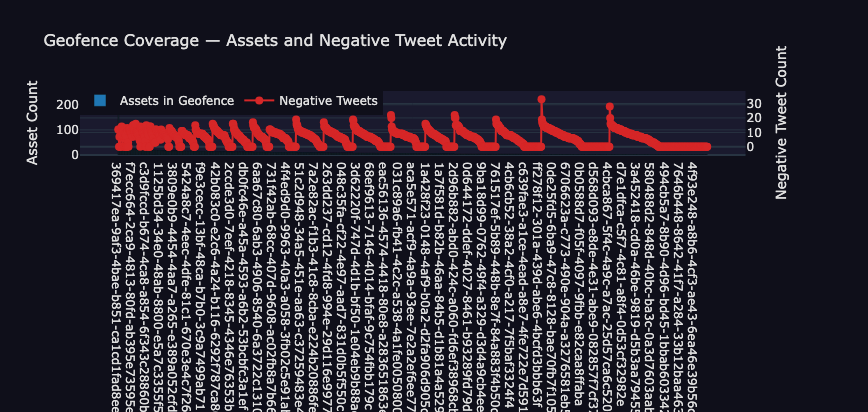

26/05/26 16:17:47 ERROR ExecutionListenerBus: Listener SqlListener threw an exception
org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `geofence_geometry` cannot be resolved. Did you mean one of the following? [`fence_tweet_count`, `af`.`in_geofence`, `af`.`geofence_id`, `af`.`asset_id`, `fence_negative_tweets`]. SQLSTATE: 42703;
'Project [geofence_id#4605, fence_tweet_count#4603L, fence_negative_tweets#4604L, fence_avg_sentiment#4610, 'geofence_geometry]
+- Sort [fence_negative_tweets#4604L DESC NULLS LAST], true
   +- Project [asset_id#455, geofence_id#4605, in_geofence#4606, coalesce(fence_tweet_count#4608L, cast(0 as bigint)) AS fence_tweet_count#4603L, coalesce(fence_negative_tweets#4609L, cast(0 as bigint)) AS fence_negative_tweets#4604L, fence_avg_sentiment#4610]
      +- Join LeftOuter, (geofence_id#4605 = geofence_id#4607)
         :- SubqueryAlias af
         :  +- SubqueryAlias asset_in_fence
    

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `geofence_geometry` cannot be resolved. Did you mean one of the following? [`fence_tweet_count`, `af`.`in_geofence`, `af`.`geofence_id`, `af`.`asset_id`, `fence_negative_tweets`]. SQLSTATE: 42703;
'Project [geofence_id#4605, fence_tweet_count#4603L, fence_negative_tweets#4604L, fence_avg_sentiment#4610, 'geofence_geometry]
+- Sort [fence_negative_tweets#4604L DESC NULLS LAST], true
   +- Project [asset_id#455, geofence_id#4605, in_geofence#4606, coalesce(fence_tweet_count#4608L, cast(0 as bigint)) AS fence_tweet_count#4603L, coalesce(fence_negative_tweets#4609L, cast(0 as bigint)) AS fence_negative_tweets#4604L, fence_avg_sentiment#4610]
      +- Join LeftOuter, (geofence_id#4605 = geofence_id#4607)
         :- SubqueryAlias af
         :  +- SubqueryAlias asset_in_fence
         :     +- SubqueryAlias asset_in_fence
         :        +- Project [asset_id#455, id#4612 AS geofence_

In [22]:
# =============================================================================
# Step 9 Visualization -- Geofence Asset Overlay
# =============================================================================

geofence_pd = geofence_asset_overlay.groupBy("geofence_id").agg(
    F.count("asset_id").alias("asset_count"),
    F.first("fence_tweet_count").alias("tweet_count"),
    F.first("fence_negative_tweets").alias("negative_tweets"),
    F.first("fence_avg_sentiment").alias("avg_sentiment"),
).orderBy(F.desc("asset_count")).toPandas()

plot_setup_step9_geofence(geofence_pd)

# --- SedonaKepler: geofence polygons colored by negative tweet intensity ---
geofence_map_df = geofence_asset_overlay.select(
    "geofence_id", "fence_tweet_count", "fence_negative_tweets",
    "fence_avg_sentiment", "geofence_geometry"
).distinct()

geofence_map = SedonaKepler.create_map(df=geofence_map_df, name="Geofence Overlay")
geofence_map

---
## Step 10 -- Enhanced Vulnerability Score

Composite weighted score combining all hazard proximity layers, criticality, and
**social media signal** into a single **enhanced vulnerability score** per asset.
Also identifies assets in **multi-hazard overlap zones** and with **social alert** flags.

**Reuses cached temp views** from Steps 3-9 (no redundant spatial joins):
- `flood_proximity` → flood water count per asset
- `wildfire_proximity` → wildfire land cover count per asset
- `settlement_proximity` → facility count per asset
- `building_density` → building count per asset
- `asset_criticality` → criticality tier per asset
- `social_media_proximity` → tweet counts and sentiment per asset

**Scoring formula (5 components):**
```
vulnerability_score = 0.25 * flood_count
                    + 0.25 * wildfire_count
                    + 0.15 * (facility_count + 0.01 * building_count)
                    + 0.20 * criticality_tier * 100
                    + 0.15 * social_signal
```

Where `social_signal = negative_tweet_count * 2 + neutral_tweet_count * 0.5`
(negative sentiment near infrastructure weighs heavier).

**Flags:**
- `multi_hazard_flag`: TRUE when both flood AND wildfire counts > 0
- `social_alert_flag`: TRUE when negative_tweet_count >= 3 near asset

**Source:** `sql/07_multi_hazard_vulnerability_score.sql`

In [ ]:
%%time
# =============================================================================
# Step 10: Enhanced vulnerability score (5-component)
# =============================================================================
# LEFT JOINs all cached temp views to produce a composite score per asset.
# No redundant spatial joins -- all proximity data comes from cached views.

enhanced_vulnerability = sedona.sql(f"""
    SELECT
      ca.asset_id,
      ca.subtype,
      ca.class,
      ca.names,
      ca.geometry,
      ac.criticality_tier,
      COALESCE(fp.flood_water_count, 0) AS flood_count,
      COALESCE(wp.wildfire_landcover_count, 0) AS wildfire_count,
      COALESCE(sp.facility_count, 0) AS facility_count,
      COALESCE(bd.building_count, 0) AS building_count,
      COALESCE(sm.tweet_count, 0) AS tweet_count,
      COALESCE(sm.negative_tweet_count, 0) AS negative_tweet_count,
      COALESCE(sm.positive_tweet_count, 0) AS positive_tweet_count,
      COALESCE(sm.neutral_tweet_count, 0) AS neutral_tweet_count,
      sm.avg_sentiment_score,
      COALESCE(sm.total_retweets, 0) AS total_retweets,
      COALESCE(sm.total_likes, 0) AS total_likes,
      (
        {W_FLOOD}    * COALESCE(fp.flood_water_count, 0) +
        {W_WILDFIRE}  * COALESCE(wp.wildfire_landcover_count, 0) +
        {W_SETTLE}   * (COALESCE(sp.facility_count, 0) + 0.01 * COALESCE(bd.building_count, 0)) +
        {W_CRITICAL} * ac.criticality_tier * 100 +
        {W_SOCIAL}   * (COALESCE(sm.negative_tweet_count, 0) * 2 + COALESCE(sm.neutral_tweet_count, 0) * 0.5)
      ) AS vulnerability_score,
      CASE
        WHEN COALESCE(fp.flood_water_count, 0) > 0
         AND COALESCE(wp.wildfire_landcover_count, 0) > 0
        THEN TRUE
        ELSE FALSE
      END AS multi_hazard_flag,
      CASE
        WHEN COALESCE(sm.negative_tweet_count, 0) >= 3
        THEN TRUE
        ELSE FALSE
      END AS social_alert_flag
    FROM critical_assets ca
    JOIN asset_criticality ac ON ca.asset_id = ac.asset_id
    LEFT JOIN flood_proximity fp ON ca.asset_id = fp.asset_id
    LEFT JOIN wildfire_proximity wp ON ca.asset_id = wp.asset_id
    LEFT JOIN settlement_proximity sp ON ca.asset_id = sp.asset_id
    LEFT JOIN building_density bd ON ca.asset_id = bd.asset_id
    LEFT JOIN social_media_proximity sm ON ca.asset_id = sm.asset_id
    ORDER BY vulnerability_score DESC
""")

enhanced_vulnerability = enhanced_vulnerability.cache()
enhanced_vulnerability.createOrReplaceTempView("enhanced_vulnerability")

vuln_count = enhanced_vulnerability.count()
multi_hazard_count = enhanced_vulnerability.filter(F.col("multi_hazard_flag") == True).count()
social_alert_count = enhanced_vulnerability.filter(F.col("social_alert_flag") == True).count()
print(f"Scored assets: {vuln_count:,}")
print(f"Multi-hazard overlap (flood + wildfire): {multi_hazard_count:,}")
print(f"Social alert flag (>=3 negative tweets): {social_alert_count:,}")

In [ ]:
# =============================================================================
# Step 10 Visualization -- Enhanced Vulnerability Score
# =============================================================================

# --- SedonaKepler: HERO MAP — assets sized/colored by vulnerability score ---
hero_df = enhanced_vulnerability.select(
    "asset_id", "class", "criticality_tier",
    "flood_count", "wildfire_count", "facility_count",
    "negative_tweet_count", "multi_hazard_flag", "social_alert_flag",
    F.round("vulnerability_score", 2).alias("vulnerability_score"),
    "geometry",
)
hero_map = SedonaKepler.create_map(df=hero_df, name="Vulnerability Score")
hero_map;


In [ ]:
# =============================================================================
# Step 10 Visualization (continued) -- Score Distribution & Multi-hazard Bubble
# =============================================================================

vuln_pd = enhanced_vulnerability.select(
    "asset_id", "class", "criticality_tier",
    "flood_count", "wildfire_count", "negative_tweet_count",
    F.round("vulnerability_score", 2).alias("vulnerability_score"),
    "multi_hazard_flag", "social_alert_flag",
).toPandas()

vuln_pd["flag"] = vuln_pd.apply(
    lambda r: (
        "Multi-Hazard + Alert" if r["multi_hazard_flag"] and r["social_alert_flag"]
        else "Multi-Hazard" if r["multi_hazard_flag"]
        else "Social Alert" if r["social_alert_flag"]
        else "Standard"
    ),
    axis=1,
)

plot_setup_step10_vuln_dist(vuln_pd)
plot_setup_step10_vuln_bubble(vuln_pd)

---
## Step 11 -- Persist to Havasu Tables

Write all setup results to `wherobots.geoint.*_civ` as Iceberg tables via Havasu.
This makes the context layers available for downstream MCP-driven queries,
notional overlay generation, and cross-session reuse without re-running the extraction pipeline.

Table names use `_civ` suffix to coexist with Border Corridor variants in the same database.

**Pattern** (per [Wherobots documentation](https://docs.wherobots.com/tutorials/wherobotsdb/vector-data/havasu)):
```python
sedona.sql("CREATE DATABASE IF NOT EXISTS wherobots.geoint")
df.writeTo("wherobots.geoint.<table>_civ").createOrReplace()
```

In [ ]:
%%time
# =============================================================================
# Step 11a: Create output database (shared with Border Corridor variants)
# =============================================================================

sedona.sql(f"CREATE DATABASE IF NOT EXISTS {OUTPUT_PREFIX}")

print(f"Database '{OUTPUT_PREFIX}' ready")

In [ ]:
%%time
# =============================================================================
# Step 11b: Write all context layers to Havasu (Iceberg) tables
# =============================================================================
# Uses df.writeTo(...).createOrReplace() per Wherobots documentation:
# https://docs.wherobots.com/tutorials/wherobotsdb/vector-data/havasu
# Table names use _civ suffix to coexist with Border Corridor variants.

# Table name mapping: base name -> DataFrame
TABLES = {
    "aoi_localities":           aoi_localities,
    "critical_assets":          critical_assets,
    "flood_proximity":          flood_proximity,
    "wildfire_proximity":       wildfire_proximity,
    "settlement_proximity":     settlement_proximity,
    "building_density":         building_density,
    "asset_criticality":        asset_criticality,
    "seasonal_vulnerability":   seasonal_vulnerability,
    "social_media_proximity":   social_media_proximity,
    "geofence_asset_overlay":   geofence_asset_overlay,
    "enhanced_vulnerability":   enhanced_vulnerability,
}

for table_name, df in TABLES.items():
    fqn = f"{OUTPUT_PREFIX}.{table_name}{TABLE_SUFFIX}"
    df.writeTo(fqn).createOrReplace()
    row_count = sedona.table(fqn).count()
    print(f"  Wrote {fqn:<60s} ({row_count:,} rows)")

print()
print("All tables persisted.")

In [ ]:
# =============================================================================
# Step 11c: Verify persisted tables
# =============================================================================

tables_pd = sedona.sql(f"SHOW TABLES IN {OUTPUT_PREFIX}").toPandas()

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in tables_pd.columns],
        fill_color="#1f3a5f",
        font=dict(color="white", size=13),
        align="left",
        height=32,
    ),
    cells=dict(
        values=[tables_pd[c] for c in tables_pd.columns],
        fill_color="#0f0f1a",
        font=dict(color="#e0e0e0", size=12),
        align="left",
        height=28,
    ),
)])
fig_table.update_layout(
    title=dict(
        text=f"Persisted Iceberg Tables in <b>{OUTPUT_PREFIX}</b>",
        font=dict(size=16, color="#e0e0e0"),
        x=0,
    ),
    paper_bgcolor="#0f0f1a",
    margin=dict(l=10, r=10, t=60, b=10),
    height=max(200, 50 + len(tables_pd) * 32),
)
fig_table.show()

# Spot-check: top 5 vulnerable assets from the persisted table
top5_pd = sedona.sql(f"""
    SELECT asset_id, class, criticality_tier,
           flood_count, wildfire_count, negative_tweet_count,
           multi_hazard_flag, social_alert_flag,
           ROUND(vulnerability_score, 2) AS vuln_score
    FROM {OUTPUT_PREFIX}.enhanced_vulnerability{TABLE_SUFFIX}
    ORDER BY vulnerability_score DESC
    LIMIT 5
""").toPandas()

fig_spot = go.Figure(data=[go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in top5_pd.columns],
        fill_color="#3a1f5f",
        font=dict(color="white", size=13),
        align="left",
        height=32,
    ),
    cells=dict(
        values=[top5_pd[c] for c in top5_pd.columns],
        fill_color="#0f0f1a",
        font=dict(color="#e0e0e0", size=12),
        align="left",
        height=28,
    ),
)])
fig_spot.update_layout(
    title=dict(
        text=f"Top 5 Most Vulnerable Assets (persisted: {OUTPUT_PREFIX}.enhanced_vulnerability{TABLE_SUFFIX})",
        font=dict(size=15, color="#e0e0e0"),
        x=0,
    ),
    paper_bgcolor="#0f0f1a",
    margin=dict(l=10, r=10, t=60, b=10),
    height=280,
)
fig_spot.show()


---
## 13. Pipeline Summary

In [ ]:
# =============================================================================
# Pipeline Execution Summary -- Indicator Dashboard
# =============================================================================

steps = [
    ("Step 1\nAOI Localities",       aoi_count),
    ("Step 2\nCritical Assets",      asset_count),
    ("Step 3\nFlood Hits",           flood_hit_count),
    ("Step 4\nWildfire Hits",        wildfire_hit_count),
    ("Step 5a\nFacility Hits",       settle_hit_count),
    ("Step 5b\nBuilding Hits",       bld_hit_count),
    ("Step 6\nTier Scored",          crit_count),
    ("Step 7\nSeasonal Enriched",    seasonal_count),
    ("Step 8\nSocial Hits",          social_hit_count),
    ("Step 9\nGeofenced",            geofence_count),
    ("Step 10\nVuln Scored",         vuln_count),
    ("Multi-Hazard\nFlag",           multi_hazard_count),
    ("Social Alert\nFlag",           social_alert_count),
]

plot_setup_pipeline_summary(
    steps,
    output_prefix=OUTPUT_PREFIX,
    table_suffix=TABLE_SUFFIX,
    geofence_table=GEOFENCE_TABLE,
    tweet_table=TWEET_TABLE,
    w_flood=W_FLOOD,
    w_wildfire=W_WILDFIRE,
    w_settle=W_SETTLE,
    w_critical=W_CRITICAL,
    w_social=W_SOCIAL,
)
print("\nReady for MCP-driven analysis and notional overlay generation.")

---
## Next Steps

With these context layers persisted to `wherobots.geoint.*_civ`, downstream workflows can:

1. **Run MCP-driven analysis** -- Use agentic Copilot prompts to query vulnerability scores,
   identify multi-hazard overlap zones, correlate social sentiment with infrastructure risk
2. **Generate notional overlays** -- Anchor synthetic hazard events, outage reports,
   inspection statuses, and daily asset metrics to real infrastructure IDs
3. **Social media monitoring** -- Track sentiment trends near critical assets,
   identify emerging threats from negative tweet spikes within geofences
4. **Produce vulnerability briefs** -- Top-N asset ranking with explainable hazard drivers,
   social signal indicators, and seasonal exposure windows
5. **Visualize with SedonaPyDeck** -- Map critical assets color-coded by vulnerability score,
   with hazard overlay layers, geofence boundaries, and tweet heatmaps
6. **Cross-session reuse** -- Query `wherobots.geoint.*_civ` tables directly without
   re-running the extraction pipeline
7. **Cross-demo comparison** -- Compare CIV vulnerability patterns with Border Corridor
   context scores (`wherobots.geoint.*` / `*_ua` / `*_civ`) using the same database

In [ ]:
# =============================================================================
# Cleanup (run when done with downstream analysis)
# =============================================================================
# Uncomment to release cached DataFrames:

# aoi_localities.unpersist()
# ukraine_aoi.unpersist()
# critical_assets.unpersist()
# flood_proximity.unpersist()
# wildfire_proximity.unpersist()
# settlement_proximity.unpersist()
# building_density.unpersist()
# asset_criticality.unpersist()
# seasonal_vulnerability.unpersist()
# social_media_proximity.unpersist()
# geofence_asset_overlay.unpersist()
# enhanced_vulnerability.unpersist()
# print("Cleanup complete.")